In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ahmendabad_house_price.csv')

## 1.Data Understanding

In [4]:
df.head()

,name,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
0,swarnim sentossa,swarnim sentossa,let your dream of owning a flat come true with...,5009.0,2250.0,super,swarnim sentossa,flat,3,NaN
1,scarlet springs,scarlet springs,"scarlet springs is a residential project, offe...",4377.0,1674.0,super,scarlet springs,flat,3,0.7328
2,suryansh sanidhya shivalaya,"sarkhej, sarkhej okaf, ahmedabad",suryansh sanidhya shivalaya society now offers...,3931.0,1080.0,super,suryansh sanidhya shivalaya,flat,2,0.4245
3,siddhi terrace skyline,memnagar,"siddhi terrace skyline, one of the known housi...",7198.0,2320.0,super,siddhi terrace skyline,flat,3,1.6700
4,aadhya arambh,"ghatlodia, ahmedabad","beautiful 3,4 bhk apartments in ghatlodia, are...",NaN,1604.0,carpet,aadhya arambh,flat,4,NaN


In [5]:
df.shape

(20060, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20060 entries, 0 to 20059
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            19950 non-null  object 
 1   location        19765 non-null  object 
 2   description     20045 non-null  object 
 3   rate_per_sqft   19701 non-null  float64
 4   area_in_sqft    20036 non-null  float64
 5   area_type       20060 non-null  object 
 6   property_title  19949 non-null  object 
 7   property_type   20060 non-null  object 
 8   bhk_type        20060 non-null  int64  
 9   price_in_cr     19332 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.5+ MB


In [7]:
df.describe()

,rate_per_sqft,area_in_sqft,bhk_type,price_in_cr
count,1.970100e+04,2.003600e+04,20060.000000,19332.000000
mean,1.375771e+04,3.123944e+03,2.903988,1.462586
std,2.134984e+05,7.027497e+04,1.207127,2.101026
min,0.000000e+00,1.000000e+00,1.000000,0.010000
25%,4.620000e+03,1.000000e+03,2.000000,0.550000
50%,6.153000e+03,1.500000e+03,3.000000,0.850000
75%,8.860000e+03,2.169000e+03,3.000000,1.550000
max,1.500000e+07,6.534000e+06,45.000000,120.000000


In [8]:
for i in df.columns:
  print(df[i].value_counts())
  print('='* 30)

name
godrej garden city             74
safal riviera aspire           71
savvy swaraaj sports living    58
godrej green glades            49
archway by adani realty        46
                               ..
hrishiraj h4                    1
sonnet opus                     1
antriksh complex                1
aaradhya apartment              1
adoor arise                     1
Name: count, Length: 7291, dtype: int64
location
science city, ahmedabad        88
godrej garden city             74
sola, ahmedabad                72
safal riviera aspire           59
savvy swaraaj sports living    55
                               ..
sentosa greenland               1
shreekar celestial living       1
shree ram residency             1
roseville                       1
on reqeust                      1
Name: count, Length: 7282, dtype: int64
description
a quiet and beautiful apartment located in heart of the city is available on sale in ahmedabad. property is nicely located with all facilities nea

## 2.Missing Value Handling

In [9]:
df.isnull().sum()

,0
name,110
location,295
description,15
rate_per_sqft,359
area_in_sqft,24
area_type,0
property_title,111
property_type,0
bhk_type,0
price_in_cr,728


In [10]:
df = df.drop(['description','name','property_title'],axis=1)

In [11]:
df.head()

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,NaN
1,scarlet springs,4377.0,1674.0,super,flat,3,0.7328
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.4245
3,memnagar,7198.0,2320.0,super,flat,3,1.6700
4,"ghatlodia, ahmedabad",NaN,1604.0,carpet,flat,4,NaN


In [12]:
def handling_missing_data(df):

    for i in df.columns:
        if df[i].dtype == 'object':
            df[i] = df[i].fillna(df[i].mode()[0])
        else:
            df[i] = df[i].fillna(df[i].median())
    return df

In [13]:
df = handling_missing_data(df)

In [14]:
df.head()

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,0.8500
1,scarlet springs,4377.0,1674.0,super,flat,3,0.7328
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.4245
3,memnagar,7198.0,2320.0,super,flat,3,1.6700
4,"ghatlodia, ahmedabad",6153.0,1604.0,carpet,flat,4,0.8500


In [15]:
df.isnull().sum()

,0
location,0
rate_per_sqft,0
area_in_sqft,0
area_type,0
property_type,0
bhk_type,0
price_in_cr,0


## 3.EDA

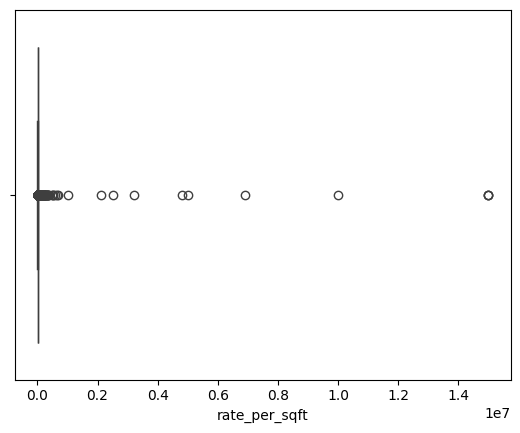

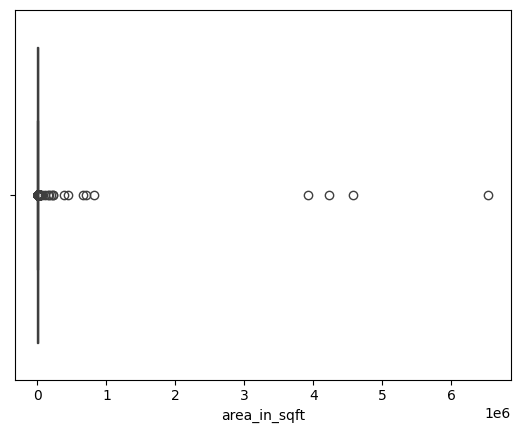

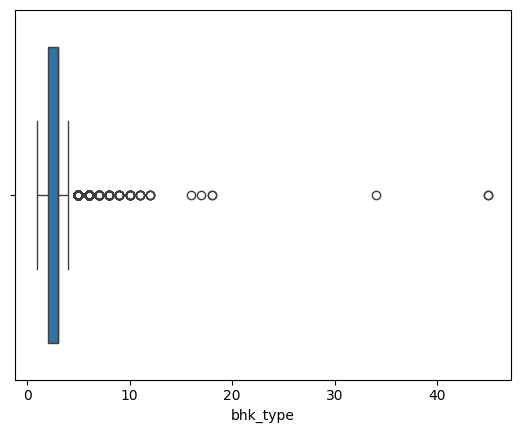

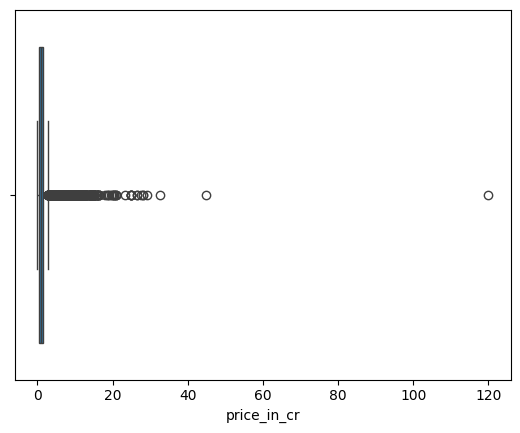

In [16]:
# Univariate Analysis

numeric_cols = ['rate_per_sqft','area_in_sqft','bhk_type','price_in_cr']

for i in numeric_cols:
    sns.boxplot(
        data=df,
        x=i

    )
    plt.xlabel(i)
    plt.show()

/tmp/ipykernel_10972/2731502228.py:19: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


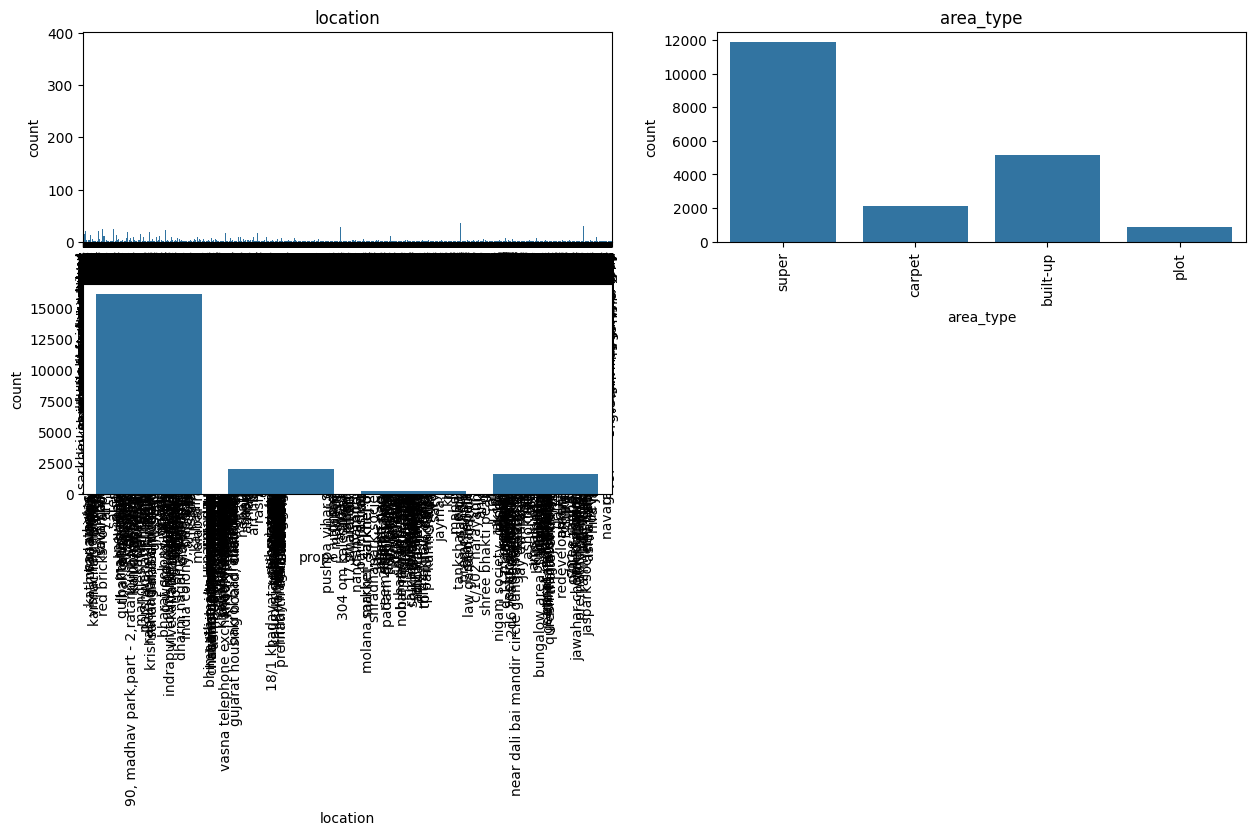

In [17]:
cat_cols = df['area_type','property_type	']
n = len(cat_cols)
cols = 2                     # Number of plots per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

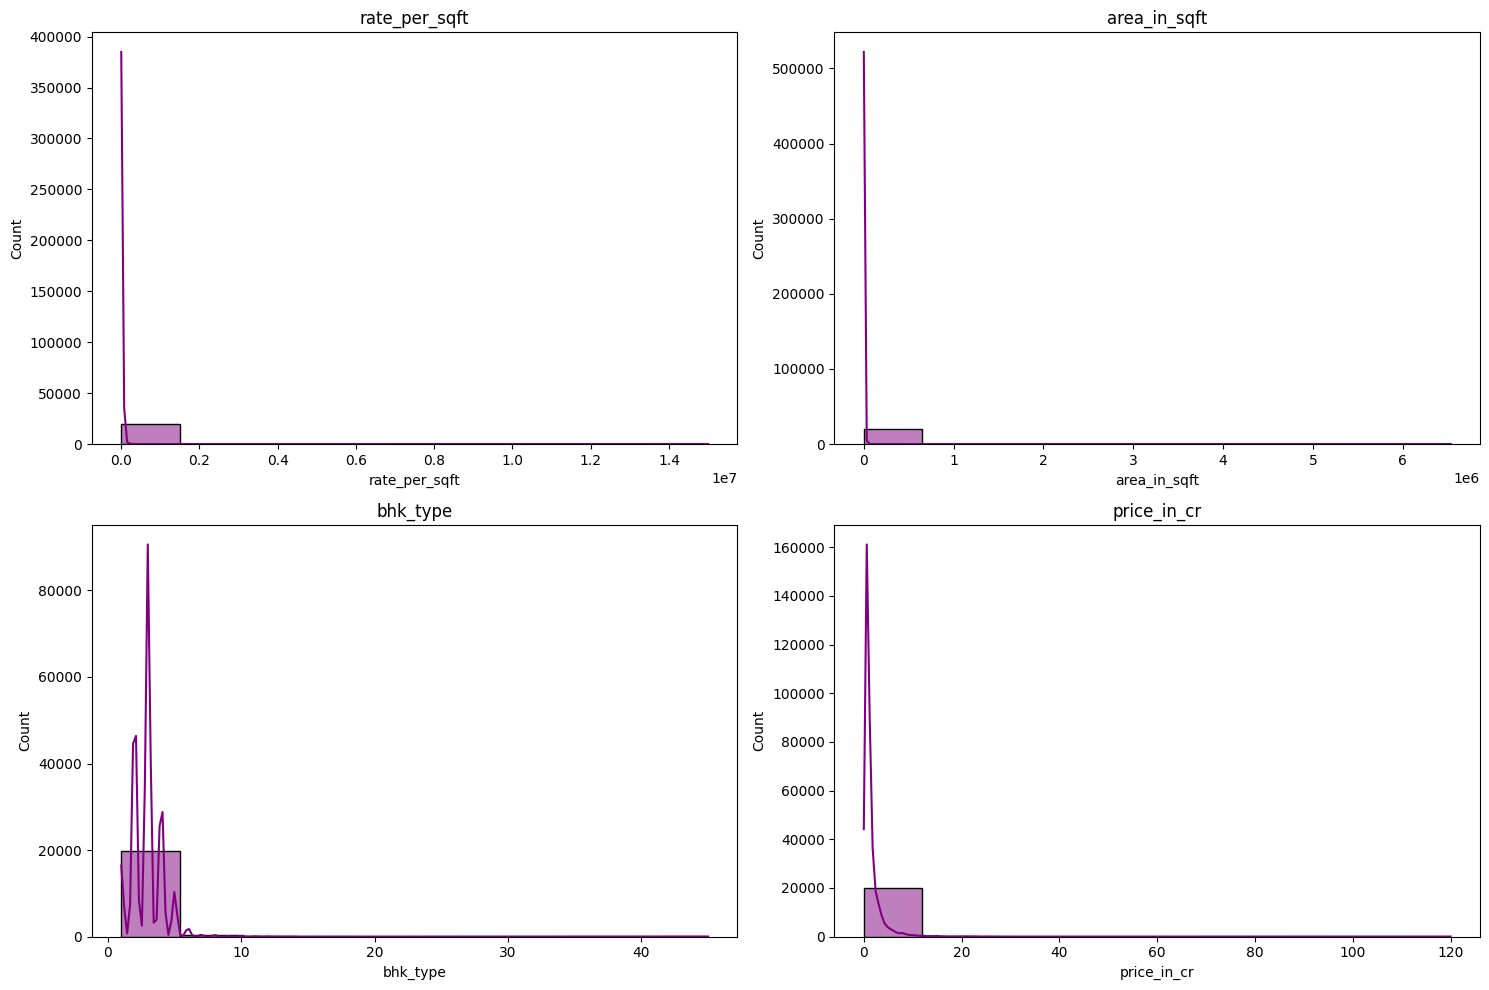

In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+1)//2,
    ncols=2,
    figsize=(15, 5*((len(num_cols)+1)//2))
)

axes = axes.flatten()

j = 0
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        sns.histplot(
            data=df,
            x=i,
            kde=True,
            ax=axes[j],
            bins = 10,
            color = 'purple'
        )
        axes[j].set_title(i)
        j += 1

# Remove empty subplots
for k in range(j, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

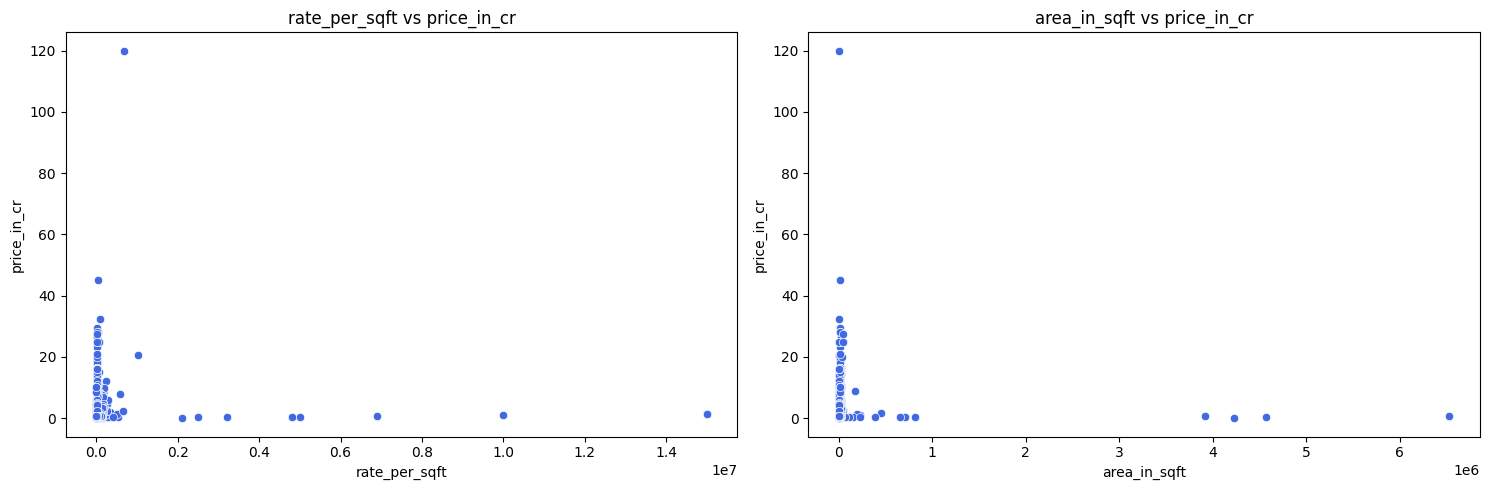

In [19]:
num_cols = ['rate_per_sqft', 'area_in_sqft']

fig, axes = plt.subplots(
    nrows=(len(num_cols)+1)//2,
    ncols=2,
    figsize=(15,5)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(
        data=df,
        x=col,
        y='price_in_cr',
        ax=axes[i],
        color='royalblue'
    )
    axes[i].set_title(f'{col} vs price_in_cr')

# Remove unused subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

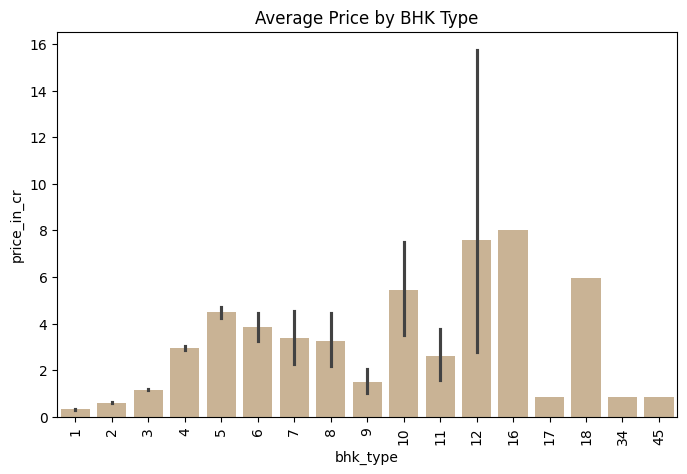

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='bhk_type',
    y='price_in_cr',
    color='tan'
)

plt.xticks(rotation=90)
plt.title('Average Price by BHK Type')
plt.show()

## 4.Handling Outliers

In [20]:
# Outlier Handling Using IQR Method

q1 = df['rate_per_sqft'].quantile(0.25)
q3 = df['rate_per_sqft'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q1 + 1.5 * iqr

outliers = df[(df['rate_per_sqft'] < lower) | (df['rate_per_sqft'] > upper)]

print(outliers.shape)

(3178, 7)


In [21]:
df['price_in_cr'].sort_values(ascending=False)

,price_in_cr
17583,120.0000
10675,45.0000
15171,32.5000
3350,29.3000
7461,28.0000
...,...
7994,0.0270
7964,0.0270
7672,0.0117
14733,0.0100
